## Import necessary packages

In [1]:
import numpy as np

from sequentialized_barnard_tests.tools.plotting import (
    compare_progress_and_get_cld,
    plot_model_comparison,
)

## Specify your statistical analysis plan before collecting policy rollouts:

In [2]:
global_confidence_level = 0.95  # Global confidence level across 6 pairwise comparisons.
max_sample_size_per_model = 15  # Maximum possible number of rollouts (per method), according to your evaluation budget.
shuffle = False  # Whether to shuffle the True/False ordering in each success array. Set to False here, assuming each True/False outcome is independent within each success_array.

## Suppose you performed some rollouts and got the following intermediate results:

In [18]:
model_name_list = [
    "Policy A",
    "Policy B",
    "Policy C",
]

progress_bins = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]  # Define progress bins from 0% to 100% in increments of 20%.

progress_array_list = [
    np.array([0.0, 0.4, 0.4, 0.2, 0.4, 1.0, 0.0, 0.4, 0.4, 0.4, 0.2, 0.4, 0.0]),  # For Method A.
    np.array([0.8, 0.8, 0.8, 1.0, 0.8, 0.6, 0.8, 0.8, 0.8, 0.4, 1.0, 0.0, 0.6]),  # For Method B.
    np.array([0.6, 0.4, 0.4, 0.4, 0.6, 0.4, 1.0, 0.4, 0.4, 1.0, 1.0, 0.4, 0.0]),  # For Method C.
]

## Run the statistical test at any time during your experiment:

In [19]:
cld_dict = compare_progress_and_get_cld(
    model_name_list,
    progress_array_list,
    global_confidence_level,
    verbose=True,
)
cld_list = [cld_dict[key] for key in model_name_list]

Statistical Test Specs:
  Method: Welch's T-test
  Global Confidence: 0.95
    (0.98333 per comparison)
Statistical Test Results (Compact Letter Display):
  CLD for Policy B: a
    Average Perf over 13 trials = 0.708
  CLD for Policy C: ab
    Average Perf over 13 trials = 0.538
  CLD for Policy A: b
    Average Perf over 13 trials = 0.323
Not all models were separated with global confidence of 0.95. Models that share a same letter are not separated from each other with statistical significance. For more information on how to interpret the letters, see: https://en.wikipedia.org/wiki/Compact_letter_display.



/home/harukinishimura/Documents/2025_Q4_step_improvement/sequentialized_barnard_tests/sequentialized_barnard_tests/tools/plotting.py:287: UserWarning: Policy A vs. Policy B: Sample size 13 < 50 might be too small to apply Welch's t-test.
  warnings.warn(
/home/harukinishimura/Documents/2025_Q4_step_improvement/sequentialized_barnard_tests/sequentialized_barnard_tests/tools/plotting.py:287: UserWarning: Policy A vs. Policy C: Sample size 13 < 50 might be too small to apply Welch's t-test.
  warnings.warn(
/home/harukinishimura/Documents/2025_Q4_step_improvement/sequentialized_barnard_tests/sequentialized_barnard_tests/tools/plotting.py:287: UserWarning: Policy B vs. Policy C: Sample size 13 < 50 might be too small to apply Welch's t-test.
  warnings.warn(


## Let's visualize this comparison:

Plot generated. Two models that do not share any CLD letters are significantly different.


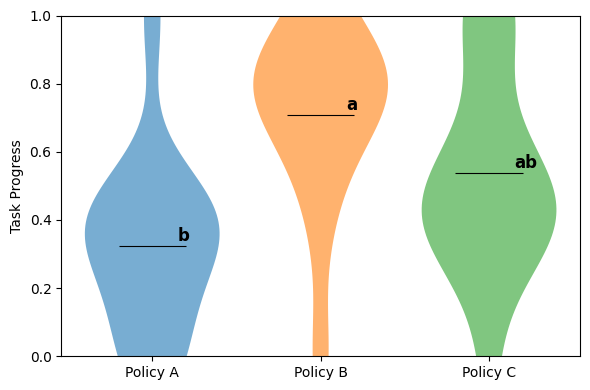

In [20]:
plot_model_comparison(
    model_name_list,
    progress_array_list,
    cld_list,
    rng=np.random.default_rng(123), # For plotting violins
    mode="task_progress",
    progress_bins=progress_bins,
)
print("Plot generated. Two models that do not share any CLD letters are significantly different.")